In [2]:
import pandas as pd
import matplotlib.pyplot as plt

yolcu = pd.read_csv("passenger_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["date"])
sefer = pd.read_csv("trips_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["Tarih"])

print(yolcu.shape, sefer.shape)
print(yolcu.dtypes)

(678010, 13) (1489, 5)
transaction_year              int64
transaction_month             int64
transaction_day               int64
line                            str
station_name                    str
age                             str
town                            str
passage_cnt                   int64
passanger_cnt                 int64
date                 datetime64[us]
weekday                         str
is_weekend                     bool
line_code                       str
dtype: object


In [4]:
yas_sirasi = ["<20", "20-30", "30-60", "60+", "Bilinmiyor"]
yolcu["age"] = pd.Categorical(yolcu["age"], categories=yas_sirasi, ordered=True)

In [5]:
hat_yolcu = yolcu.groupby("line_code")["passanger_cnt"].sum().sort_values(ascending=False)
print(hat_yolcu)

line_code
Marmaray                     211013465
M2                           144902910
T1                           107480340
M5                           105871816
M1                           104618911
M4                           102313233
M7                            75396747
T4                            57056314
M3                            49897239
M8                            24864688
M9                            24472718
T5                            20318350
M11                           10812046
M6                             5372638
F1                             3964775
TCDD SIRKECI-KAZLICESME        3897893
IETT TUNEL                     2697027
F4                             1229968
T3                              952863
TF2                             844905
IETT NOSTALJIK TRAMVAY          386438
TF1                             221489
TCDD - HALKALI-BASAKSEHIR       112429
Name: passanger_cnt, dtype: int64


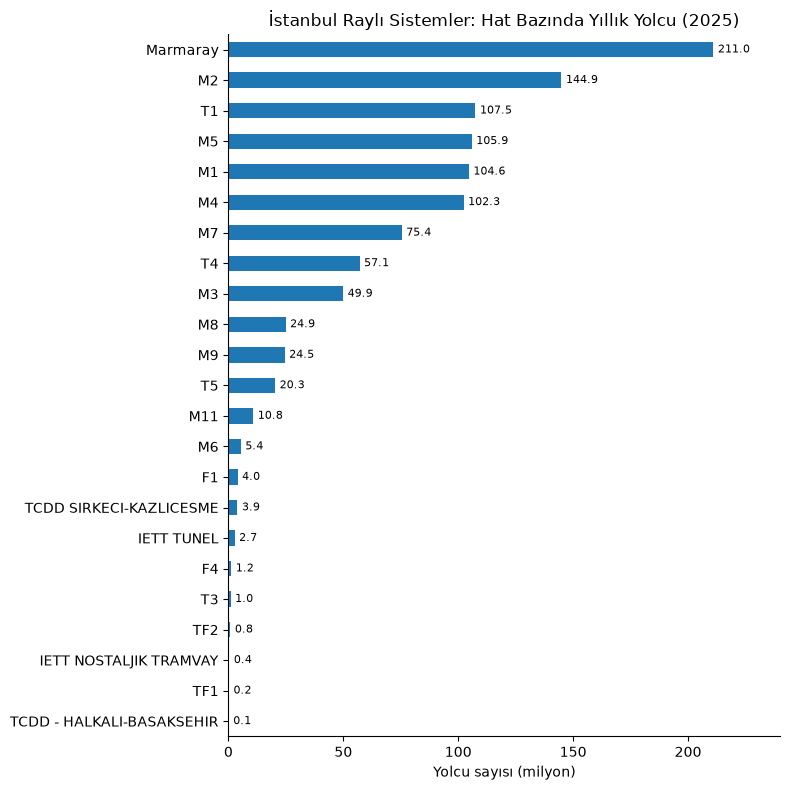

In [11]:
veri = (hat_yolcu / 1_000_000).sort_values()
ax = veri.plot(kind="barh", figsize=(8, 8))

for i, deger in enumerate(veri):
    ax.text(deger + 2, i, f"{deger:.1f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)

plt.title("İstanbul Raylı Sistemler: Hat Bazında Yıllık Yolcu (2025)")
plt.xlabel("Yolcu sayısı (milyon)")
plt.ylabel("")
plt.xlim(0, 240)
plt.tight_layout()
plt.savefig("figures/hat_bazli_yolcu.png", dpi=150)
plt.show()